In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\healthcare_fraud_detection.csv")

print(df.shape)
df.head()

(10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ADMIN\Downloads\healthcare_fraud_detection.csv")

print(df.shape)
print(df.head())

(10000, 20)
  Provider_ID  Claim_ID  Patient_Age Patient_Gender Diagnosis_Code  \
0       P0052  C0000000           37           Male         I25.10   
1       P0121  C0000001           21         Female          E11.9   
2       P0140  C0000002           78         Female          J06.9   
3       P0202  C0000003           65           Male            I10   
4       P0135  C0000004           36           Male          M54.5   

   Procedure_Code  Claim_Amount  Approved_Amount Insurance_Type  \
0           36415        443.51           393.16       Medicaid   
1           99213        467.50           461.33       Self-Pay   
2           93000        591.69           530.06       Medicaid   
3           93000        235.15           189.11        Private   
4           85025        487.96           369.91        Private   

  Claim_Submission_Date  Days_Between_Service_and_Claim  \
0            2024-09-01                              13   
1            2022-09-05                       

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [4]:
print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

Dataset Shape
(10000, 20)

Columns
['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender', 'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Insurance_Type', 'Claim_Submission_Date', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay', 'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m']

Data Types
Provider_ID                               object
Claim_ID                                  object
Patient_Age                                int64
Patient_Gender                            object
Diagnosis_Code                            object
Procedure_Code                             int64
Claim_Amount                             float64
Approved_Amount                          float64
Insurance_Type                            object
Claim_Submission_Date                     object
Days_Between_Service_and_Claim             int64
Number_of_Claims_Pe

Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64


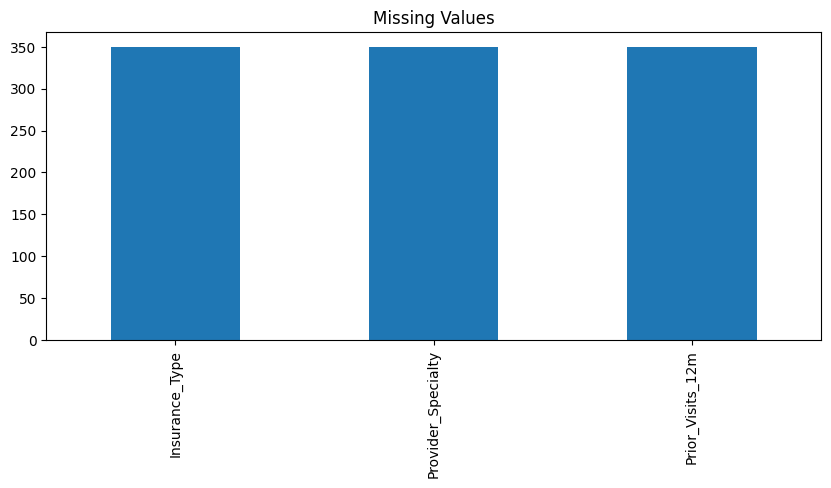

In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

plt.figure(figsize=(10,4))
missing.sort_values().plot(kind="bar")
plt.title("Missing Values")
plt.show()

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


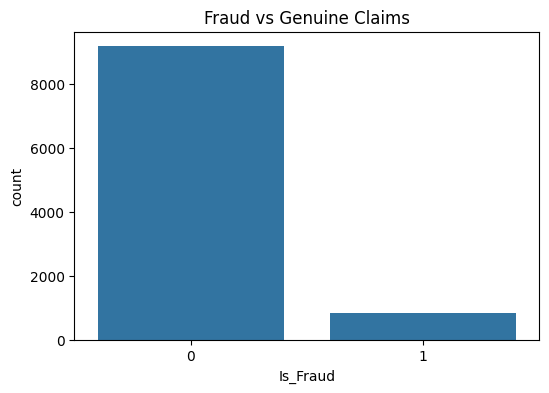

Is_Fraud
0    9171
1     829
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="Is_Fraud", data=df)

plt.title("Fraud vs Genuine Claims")

plt.show()

print(df["Is_Fraud"].value_counts())

In [8]:
fraud = df["Is_Fraud"].value_counts(normalize=True)*100

print(fraud)

Is_Fraud
0    91.71
1     8.29
Name: proportion, dtype: float64


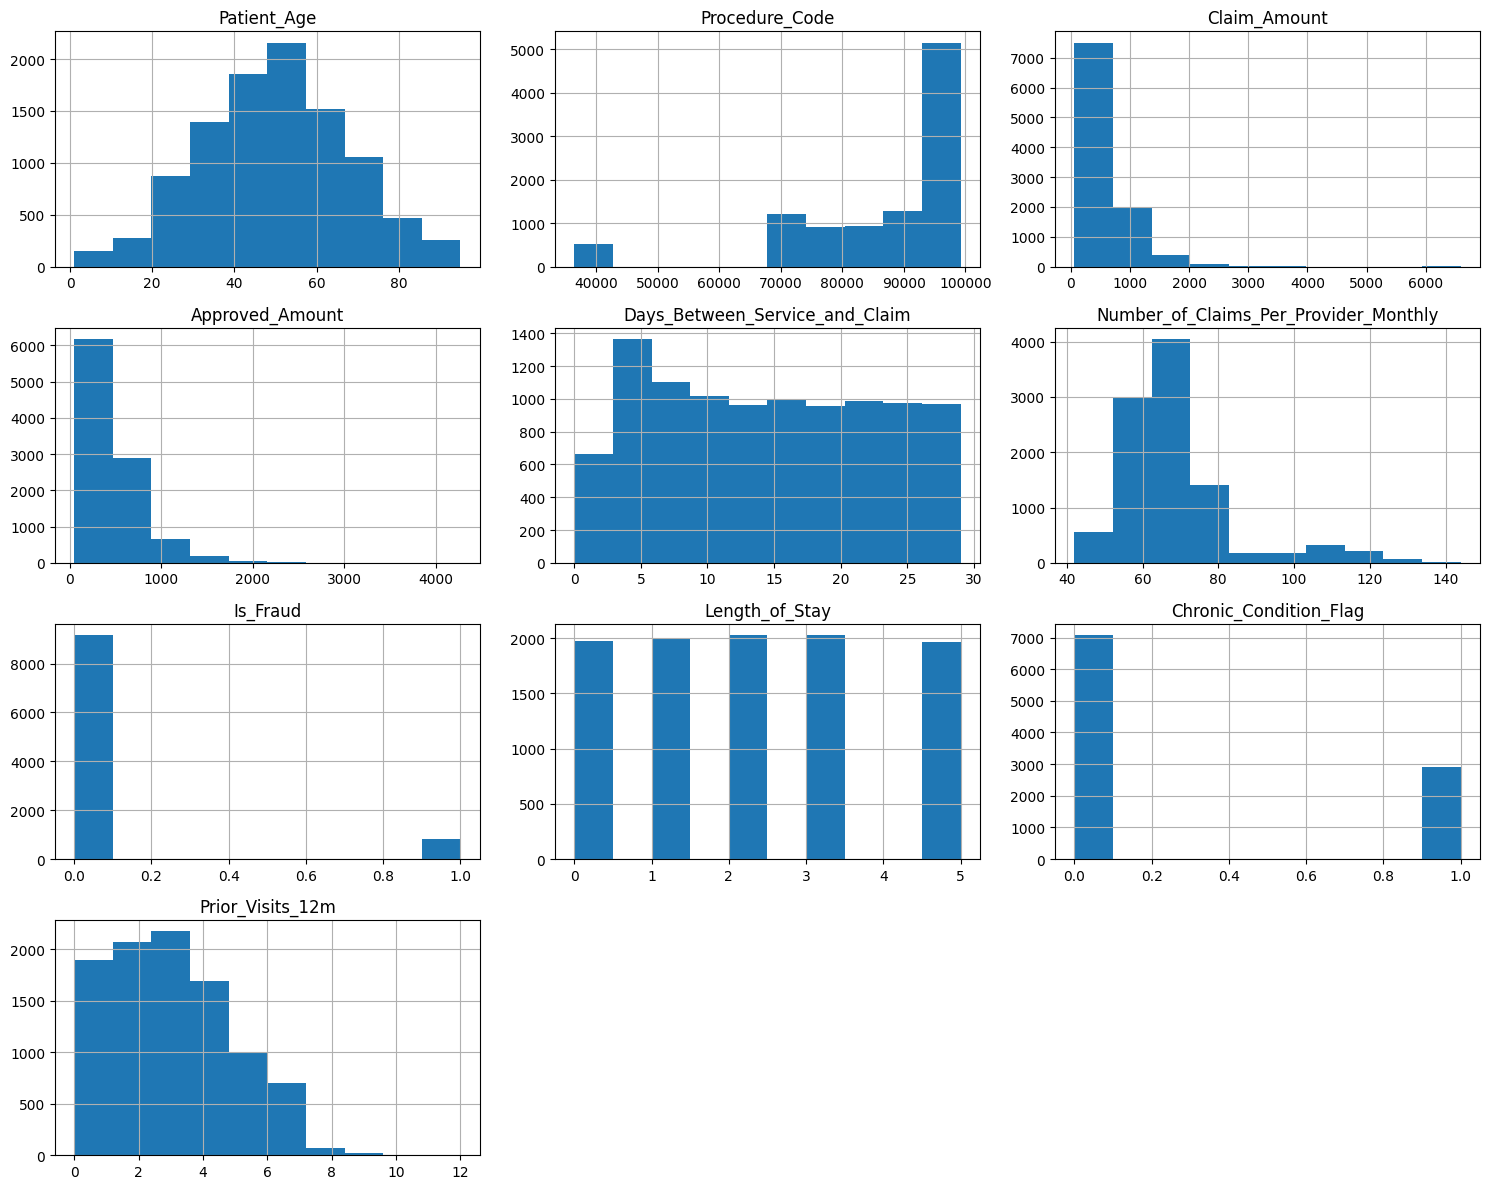

In [9]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols].hist(figsize=(15,12))

plt.tight_layout()

plt.show()

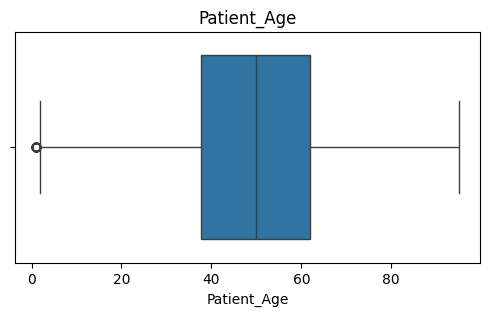

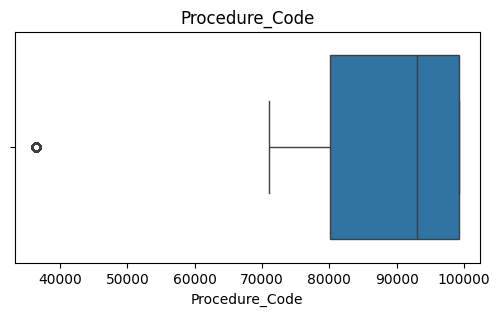

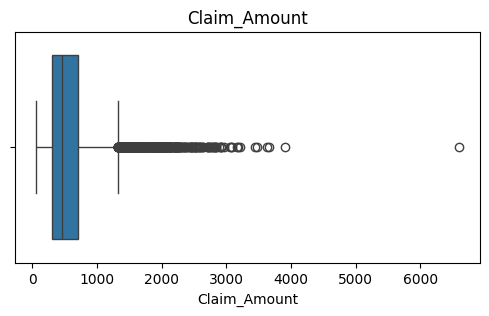

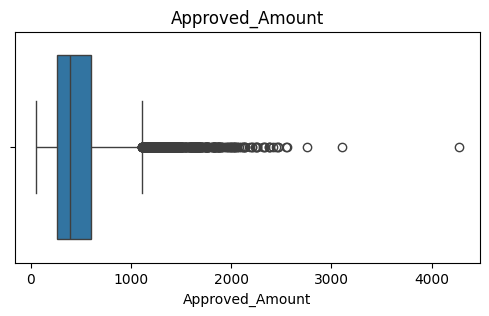

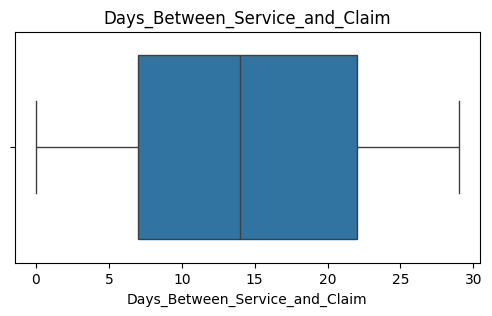

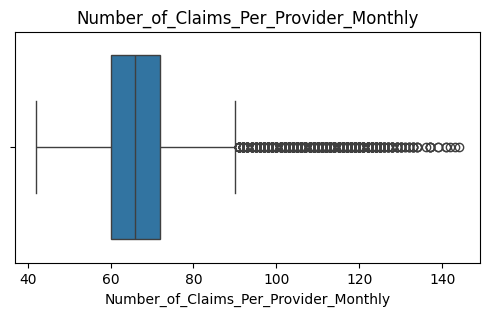

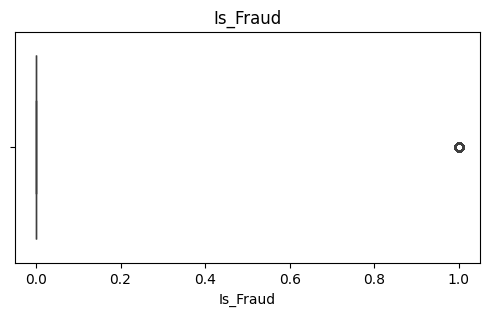

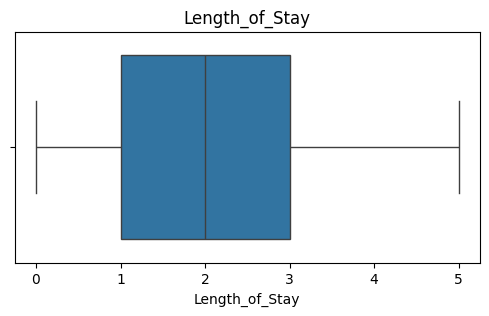

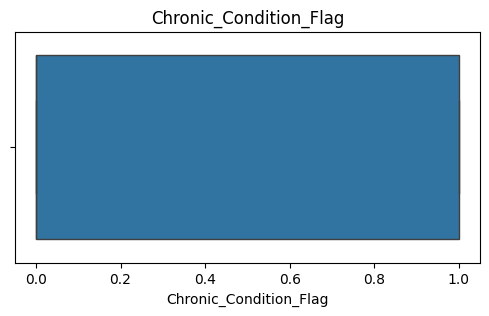

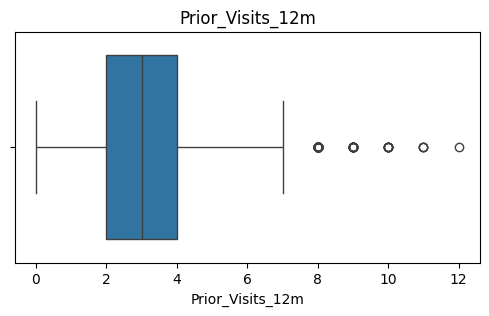

In [10]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

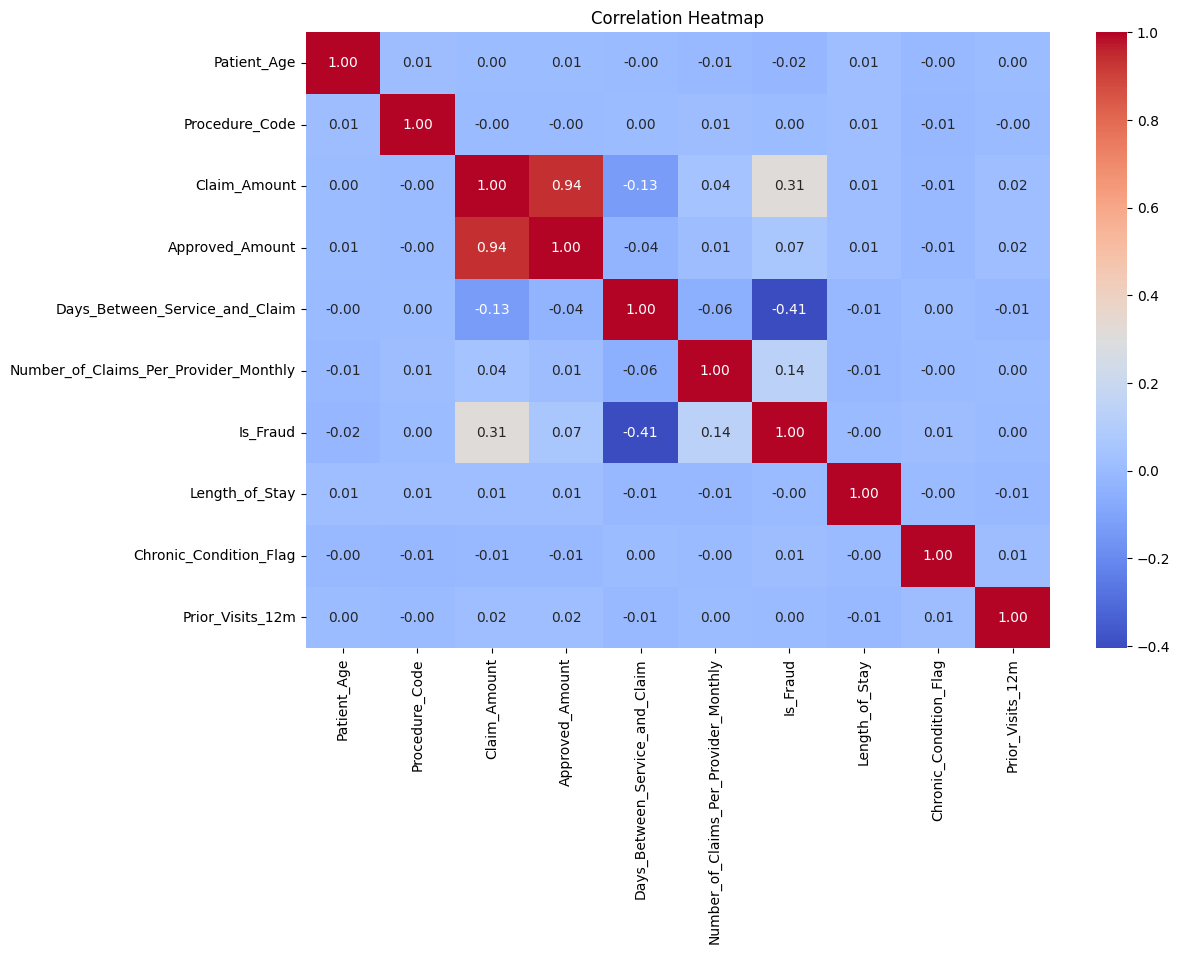

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

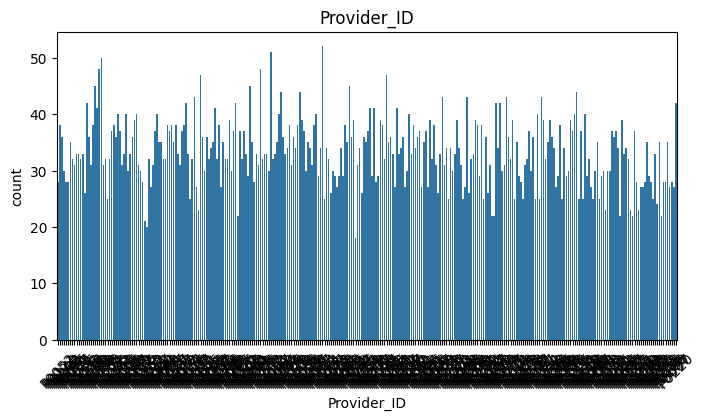

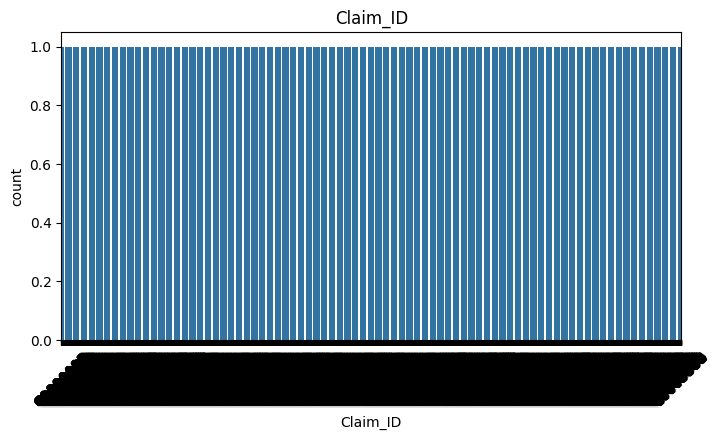

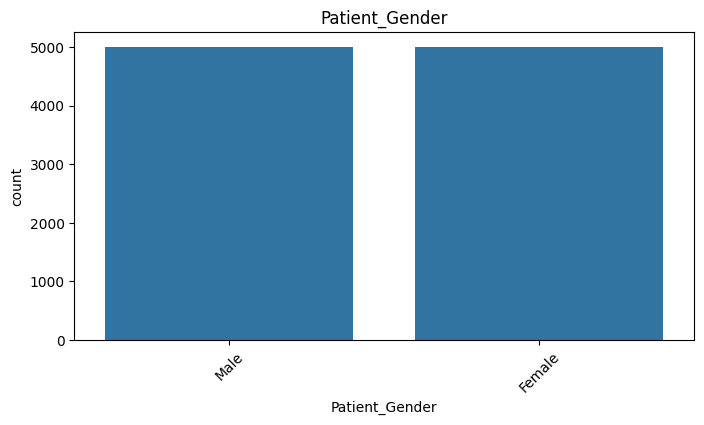

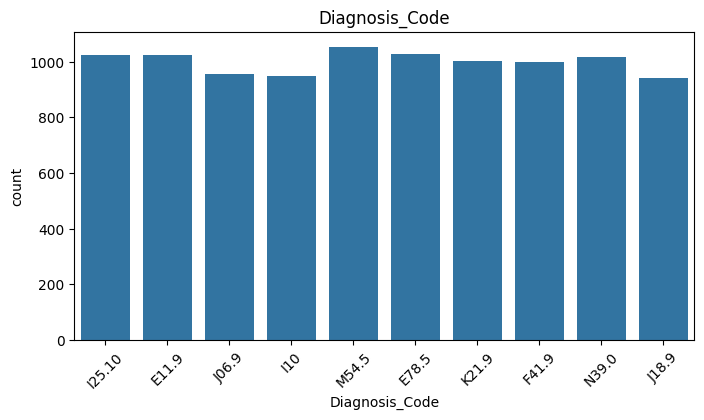

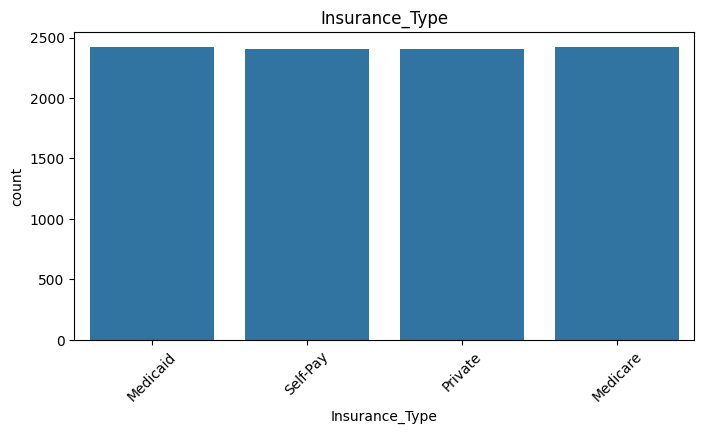

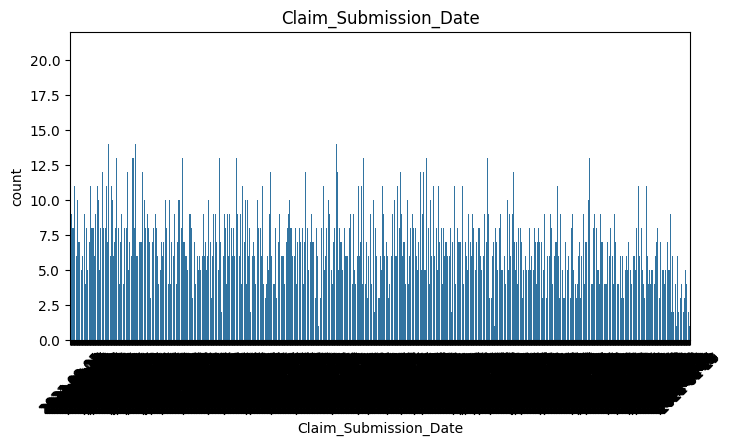

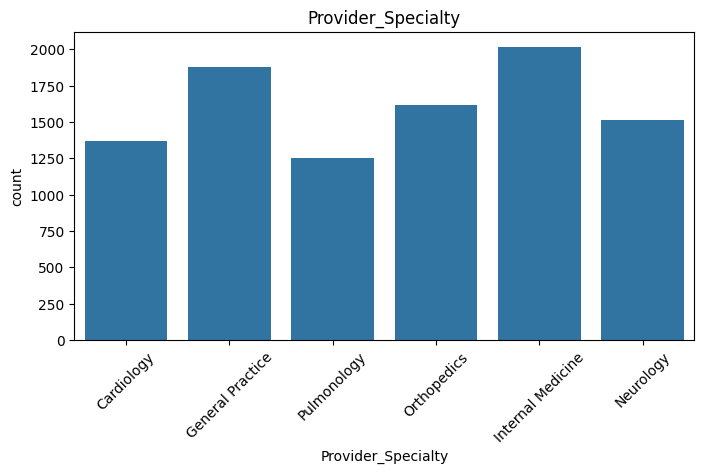

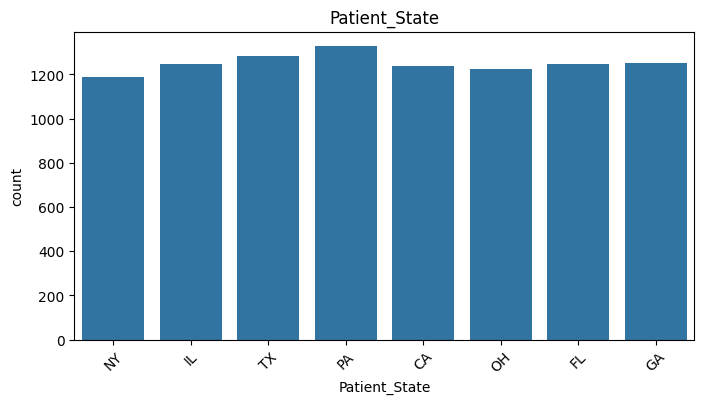

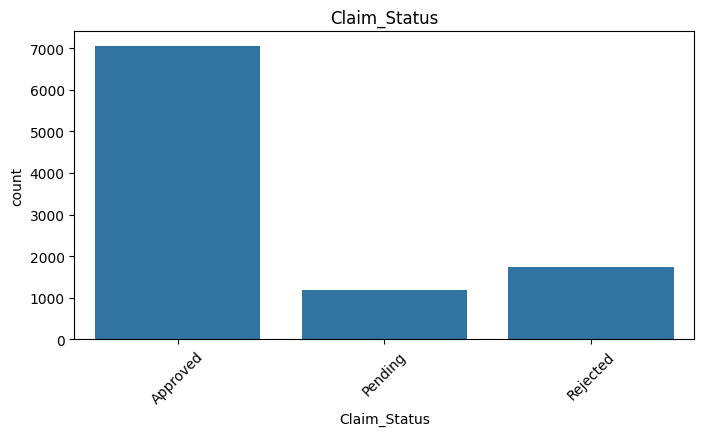

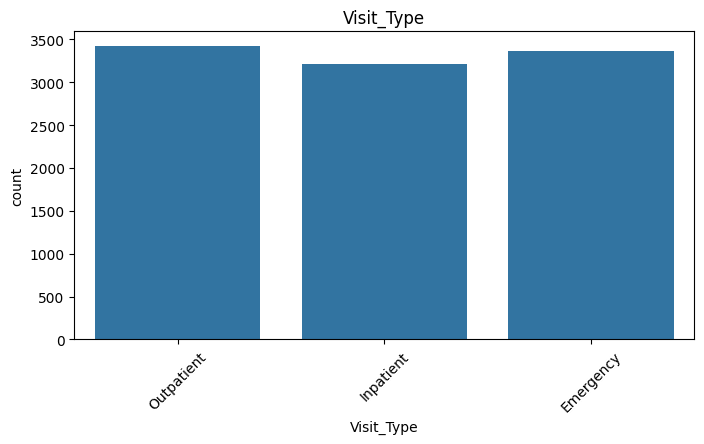

In [12]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(x=col,
                  data=df)

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

In [13]:
print(df.columns)

Index(['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender',
       'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Insurance_Type', 'Claim_Submission_Date',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay',
       'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')


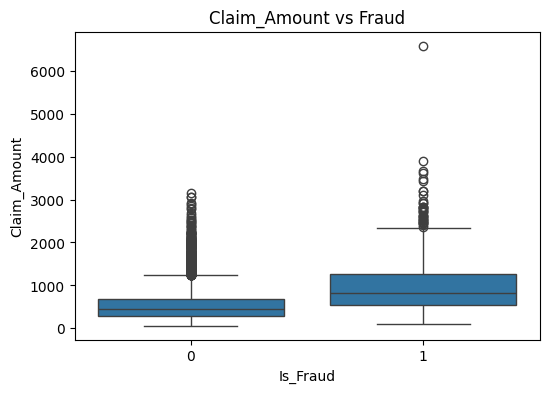

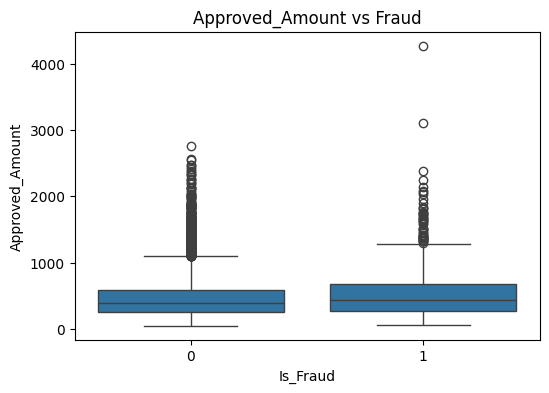

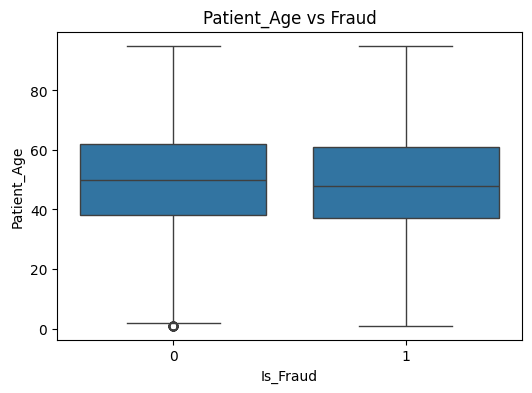

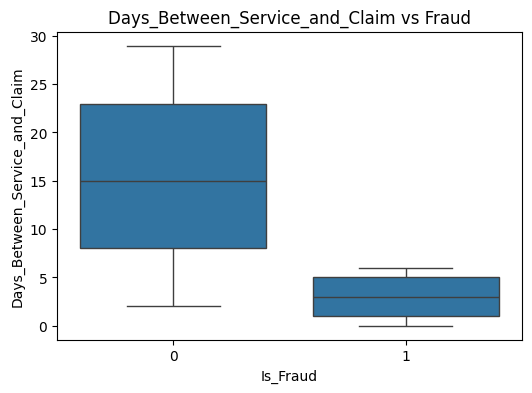

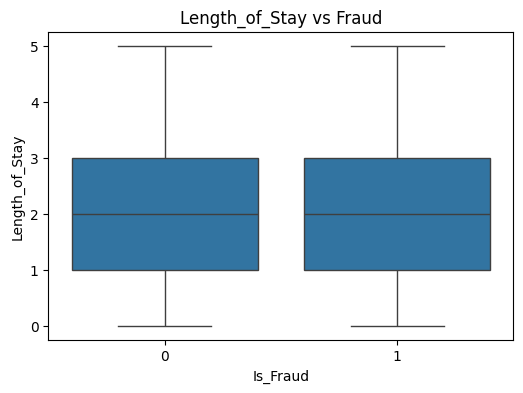

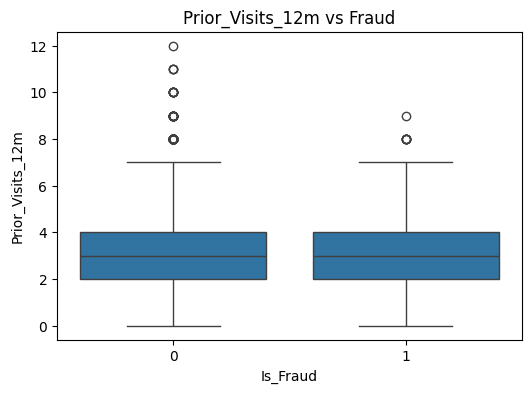

In [14]:
important = [
    "Claim_Amount",
    "Approved_Amount",
    "Patient_Age",
    "Days_Between_Service_and_Claim",
    "Length_of_Stay",
    "Prior_Visits_12m"
]

for col in important:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Is_Fraud",
        y=col
    )

    plt.title(f"{col} vs Fraud")

    plt.show()

In [15]:
display(df.describe())

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [16]:
print("EDA Completed Successfully")

EDA Completed Successfully


PHASE-3 
Data Preprocessing

In [17]:
import pandas as pd
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
print("Duplicates Before :", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After :", df.duplicated().sum())

Duplicates Before : 0
Duplicates After : 0


In [ ]:
df["Claim_Submission_Date"] = pd.to_datetime(
    df["Claim_Submission_Date"],
    errors="coerce"
)

In [ ]:
print(df.isnull().sum())

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64


In [ ]:
df = df.drop(
    columns=[
        "Provider_ID",
        "Claim_ID"
    ]
)

In [ ]:
X = df.drop("Is_Fraud", axis=1)
y = df["Is_Fraud"]

In [ ]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns

cat_cols = X.select_dtypes(include="object").columns

print("Numerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Numerical Columns
Index(['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay',
       'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')

Categorical Columns
Index(['Patient_Gender', 'Diagnosis_Code', 'Insurance_Type',
       'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type'],
      dtype='object')


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [ ]:
joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessor Saved")

Preprocessor Saved


PHASE-4
Feature Engineering

In [ ]:
df["Approval_Ratio"] = (
    df["Approved_Amount"] /
    (df["Claim_Amount"] + 1)
)

In [ ]:
threshold = df["Claim_Amount"].quantile(0.75)

df["High_Claim"] = (
    df["Claim_Amount"] > threshold
).astype(int)

In [ ]:
df["Age_Group"] = pd.cut(
    df["Patient_Age"],
    bins=[0,18,35,50,65,100],
    labels=[
        "Child",
        "Young",
        "Adult",
        "Middle",
        "Senior"
    ]
)

In [ ]:
df["Long_Stay"] = (
    df["Length_of_Stay"] >= 7
).astype(int)

In [ ]:
df["Frequent_Visitor"] = (
    df["Prior_Visits_12m"] >= 5
).astype(int)

In [ ]:
provider_threshold = df[
    "Number_of_Claims_Per_Provider_Monthly"
].quantile(0.75)

df["High_Provider_Load"] = (
    df["Number_of_Claims_Per_Provider_Monthly"] >
    provider_threshold
).astype(int)

In [ ]:
df["Claim_Delay"] = pd.cut(
    df["Days_Between_Service_and_Claim"],
    bins=[0,7,15,30,365],
    labels=[
        "Quick",
        "Normal",
        "Late",
        "Very Late"
    ]
)

In [ ]:
risk = 0

risk += df["High_Claim"]

risk += df["Long_Stay"]

risk += df["Frequent_Visitor"]

risk += df["High_Provider_Load"]

df["Risk_Score"] = risk

In [ ]:
df.to_csv(
    "engineered_data.csv",
    index=False
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [ ]:
from sklearn.model_selection import train_test_split
import joblib

In [ ]:
print(X.columns)
print(y.head())

Index(['Patient_Age', 'Patient_Gender', 'Diagnosis_Code', 'Procedure_Code',
       'Claim_Amount', 'Approved_Amount', 'Insurance_Type',
       'Claim_Submission_Date', 'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Length_of_Stay', 'Visit_Type',
       'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')
0    0
1    0
2    0
3    0
4    0
Name: Is_Fraud, dtype: int64


In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
print(X_processed.shape)
print(y.shape)

(10000, 45)
(10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("="*50)
print("Training Data")
print("="*50)
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print()

print("="*50)
print("Testing Data")
print("="*50)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Training Data
X_train : (8000, 45)
y_train : (8000,)

Testing Data
X_test : (2000, 45)
y_test : (2000,)


In [ ]:
print("Training Distribution")
print(y_train.value_counts(normalize=True) * 100)

print()

print("Testing Distribution")
print(y_test.value_counts(normalize=True) * 100)

Training Distribution
Is_Fraud
0    91.7125
1     8.2875
Name: proportion, dtype: float64

Testing Distribution
Is_Fraud
0    91.7
1     8.3
Name: proportion, dtype: float64


In [ ]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

print("All files saved successfully.")

All files saved successfully.
